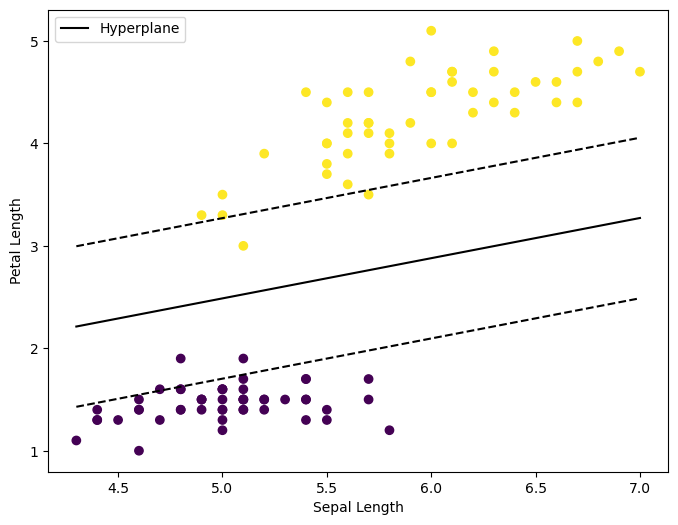

In [62]:
#SVM from scratch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class SVM:
    def __init__(self, lr=0.001, lambda_param=0.01, n_iters=1000):
        self.lr = lr
        self.lambda_param = lambda_param
        self.n_iters = n_iters

    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        #convertir labels en -1 / +1
        y_ = np.where(y == 0, -1, 1)

        #initialisation des parametre
        self.w = np.zeros(n_features)
        self.b = 0

        #descente de gradient
        for _ in range(self.n_iters):
            for i, x_i in enumerate(X):
                 # Vérifier si le point respecte la marge
                condition = y_[i] * (np.dot(x_i, self.w) - self.b) >= 1

                if condition:
                     # si le point est bien classe
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    #mise a jour si nes pas bien classe
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[i]))
                    self.b -= self.lr * y_[i]

    def predict(self, X):
        #Calcul de la prédiction
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)

df = pd.read_csv("Iris.csv")

df_binary = df[df['Species'] != 'Iris-virginica']

X = df_binary[['SepalLengthCm','PetalLengthCm']].values
y_labels = df_binary['Species'].values

#encodage manuel
unique = list(set(y_labels))
label_map = {label: i for i, label in enumerate(unique)}
y = np.array([label_map[label] for label in y_labels])


#Entraînement

model = SVM(lr=0.001, lambda_param=0.01, n_iters=1000)
model.fit(X, y)


#Visualisation

plt.figure(figsize=(8,6))

#points
plt.scatter(X[:,0], X[:,1], c=y)

#hyperplan
def hyperplane(x, w, b, offset):
    return (-w[0]*x + b + offset) / w[1]

x0 = np.linspace(X[:,0].min(), X[:,0].max(), 100)

#ligne centrale
y0 = hyperplane(x0, model.w, model.b, 0)

#marge
y1 = hyperplane(x0, model.w, model.b, 1)
y_1 = hyperplane(x0, model.w, model.b, -1)

plt.plot(x0, y0, 'k-', label="Hyperplane")
plt.plot(x0, y1, 'k--')
plt.plot(x0, y_1, 'k--')

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")

plt.legend()

plt.show()

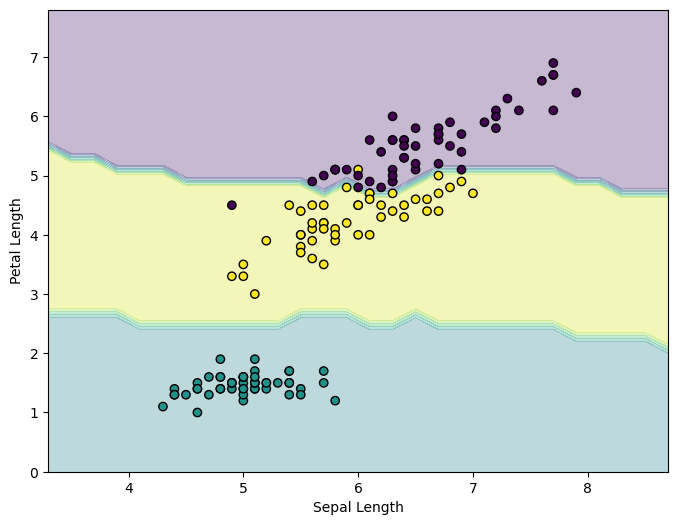

In [61]:
#KNN from scratch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

class KNN:
    def __init__(self, k=5):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
    #Calcul de la distance euclidienne entre deux points
    def distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def predict_point(self, x):
        #Calculer la distance entre le point x et tous les points d'entraînement
        distances = []
        for i in range(len(self.X_train)):
            d = self.distance(x, self.X_train[i])
            distances.append((d, self.y_train[i]))

        #tri par distance
        distances.sort(key=lambda x: x[0])

        #prendre les k plus proches
        k_nearest = distances[:self.k]

        #Extraire leurs labels
        labels = [label for _, label in k_nearest]
        #Trouver la classe la plus fréquente
        values, counts = np.unique(labels, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, X):
        #Prédire la classe pour chaque point de X
        predictions = []
        for x in X:
            predictions.append(self.predict_point(x))
        return np.array(predictions)


df = pd.read_csv("Iris.csv")

X = df[['SepalLengthCm', 'PetalLengthCm']].values
y_labels = df['Species'].values

#Encodage manuel
unique_labels = list(set(y_labels))
label_to_int = {label: i for i, label in enumerate(unique_labels)}
y = np.array([label_to_int[label] for label in y_labels])


#Entraînement

model = KNN(k=5)
model.fit(X, y)


#scalling

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.2),
    np.arange(y_min, y_max, 0.2)
)


#Prédiction

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)


#Visualisation

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    edgecolors='k'
)

plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")


plt.show()

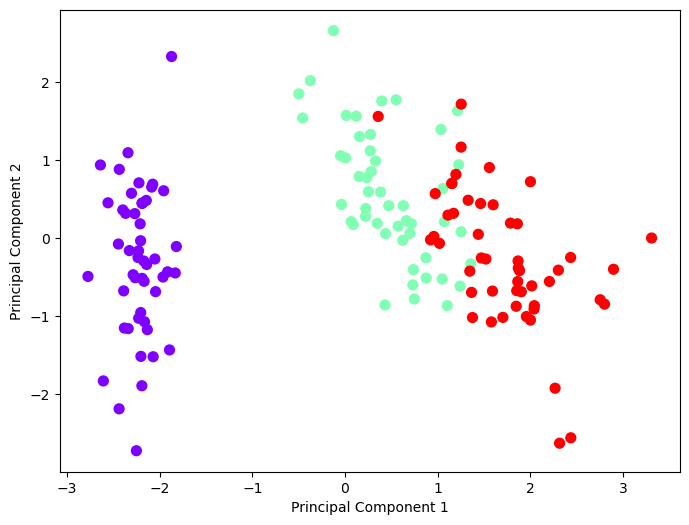

In [33]:
#Principal Component Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# charger le dataset
df = pd.read_csv("Iris.csv")

# supprimer la colonne Id
df = df.drop("Id", axis=1)

# variables numériques
X = df[[
    "SepalLengthCm",
    "SepalWidthCm",
    "PetalLengthCm",
    "PetalWidthCm"
]].values
y = df["Species"].values

# calcul moyenne
mean = np.mean(X, axis=0)
# calcul écart type
std = np.std(X, axis=0)
# normalisation
X = (X - mean) / std
 
# matrice de covariance
cov_matrix = np.cov(X.T)

# calcul des valeurs propres et vecteurs propres
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

# trier les valeurs propres du plus grand au plus petit
sorted_index = np.argsort(eigen_values)[::-1]

eigen_values = eigen_values[sorted_index]

eigen_vectors = eigen_vectors[:, sorted_index]

# choisir les 2 composantes principales
principal_components = eigen_vectors[:, :2]

# projection des données
X_pca = X @ principal_components

# visualisation

plt.figure(figsize=(8,6))

# transformer les classes en nombres
colors = pd.factorize(y)[0]

# afficher les points
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=colors,
    cmap="rainbow",
    s=50
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")



plt.show()

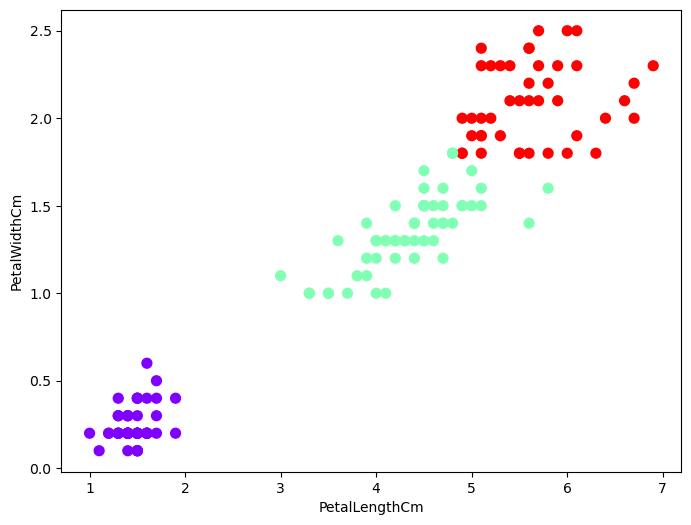

In [60]:
# XGBoost 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# charger le dataset
df = pd.read_csv("Iris.csv")
# supprimer colonne Id
df = df.drop("Id", axis=1)
# utiliser seulement 2 variables
X = df[["PetalLengthCm", "PetalWidthCm"]].values

# transformer les classes en nombres
species = {
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
}
y = df["Species"].map(species).values

# classe XGBoost simple
class SimpleXGBoost:

    def __init__(self, n_estimators=10, learning_rate=0.1, max_depth=2):
        # nombre d’arbres
        self.n_estimators = n_estimators
        # learning rate
        self.learning_rate = learning_rate
        # profondeur maximal de l'arbre
        self.max_depth = max_depth
        # stocker les arbres
        self.trees = []


    def fit(self, X, y):

        # initialisation des prédictions à 0
        y_pred = np.zeros(len(y))

        # parcourir plusieurs arbres
        for i in range(self.n_estimators):

            # calcul des résidus
            residuals = y - y_pred

            # créer arbre de décision
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth
            )

            # entraîner arbre sur les résidus
            tree.fit(X, residuals)

            # prédictions arbre
            update = tree.predict(X)

            # mise à jour des prédictions
            y_pred += self.learning_rate * update

            # sauvegarder arbre
            self.trees.append(tree)


    def predict(self, X):

        # commencer à 0
        y_pred = np.zeros(len(X))

        # additionner les prédictions des arbres
        for tree in self.trees:

            y_pred += self.learning_rate * tree.predict(X)

        # transformer en classes
        return np.round(y_pred).astype(int)

# créer modèle:
model = SimpleXGBoost(
    n_estimators=20,
    learning_rate=0.1,
    max_depth=2
)

# entraînement
model.fit(X, y)

# prédictions
predictions = model.predict(X)

# visualisation

plt.figure(figsize=(8,6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=predictions,
    cmap="rainbow",
    s=50
)

plt.xlabel("PetalLengthCm")
plt.ylabel("PetalWidthCm")


plt.show()